
# Lab 2
**Dataset:** `stats_case_study_dataset_v5.csv` (download provided)  
**Topics (only these):**
- Percentiles & Quartiles (Q1, Q2/Median, Q3), IQR, Box plot interpretation, Outliers (IQR rule)
- Histogram, Bar, Pie, Frequency tables, KDE
- Distribution shapes (normal/skewed), modality, visual outliers
- Scatter plots, Covariance & Pearson Correlation, Positive/Negative/No correlation, Correlation ≠ Causation
- Cross-tabulations and **stacked bar charts**; Numeric vs categorical bivariate analysis

**Instructions:** Each exercise is in markdown followed by an empty code cell.  
Write any brief explanations as comments right inside your code cell.


## Setup (optional)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Percentiles, Quartiles, IQR, Box Plots, Outliers

**Exercise 1:** Load the dataset from `stats_case_study_dataset_v5.csv` into `df`. Inspect `df.head(3)` and list numeric columns you will use for this section (e.g., `salary`, `monthly_sales`, `years_experience`).

In [2]:
df=pd.read_csv(r"C:\Users\uhsna\Desktop\S\Shree\Data Analyst\Session\Statistics\Stats LAb 2\stats_case_study_dataset_v5.csv")

In [3]:
df.head(3)

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,Tech,West,Male,Bachelors,5.4,39,0,40.0,2,73527.0,0.0
1,2,Operations,South,Female,Bachelors,2.1,40,0,47.7,3,45774.0,7353.0
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0


In [4]:
df_numeric=df.select_dtypes(include='number')

In [5]:
df_numeric.head(5)

,id,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,5.4,39,0,40.0,2,73527.0,0.0
1,2,2.1,40,0,47.7,3,45774.0,7353.0
2,3,16.8,41,0,41.7,3,103869.0,6505.0
3,4,6.7,36,0,39.5,5,75929.0,4232.0
4,5,6.6,31,0,38.2,3,50906.0,24137.0


**Exercise 2:** Compute the 25th, 50th (median), and 75th percentiles for `salary` and interpret one sentence for what the **75th percentile** means.

In [6]:
q1=df['salary'].quantile(0.25)
q2=df['salary'].quantile(0.5)
q3=df['salary'].quantile(0.75)

print(q1)
print(q2)
print(q3)

51286.5
60493.5
76023.75


**Exercise 3:** Compute **IQR** for `salary` and identify **outlier cutoffs** using 1.5×IQR rule. Report the lower and upper bounds.

In [7]:
iqr=q3-q1
upper_bound= q3+1.5*iqr
lower_bound =q1-1.5*iqr

print (iqr)
print(upper_bound)
print(lower_bound)

24737.25
113129.625
14180.625


**Exercise 4:** Using the bounds above, compute how many outliers are in `salary` (below lower or above upper). Then filter a non-outlier subset `df_no_out` for further comparison.

In [8]:
### df of outliers
df_out=df[(df['salary']<lower_bound) | (df['salary']>upper_bound)]
df_out

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
76,77,Finance,West,Male,High School,4.3,32,0,39.5,4,197625.0,7002.0
93,94,Tech,South,Female,Bachelors,3.6,24,0,32.2,3,213957.0,2213.0
150,151,Operations,North,Female,High School,6.9,39,0,48.8,3,131616.0,1459.0


In [9]:
### df with no outliers
df_no_out=df[(df['salary']>=lower_bound) & (df['salary']<=upper_bound)]
df_no_out

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,Tech,West,Male,Bachelors,5.4,39,0,40.0,2,73527.0,0.0
1,2,Operations,South,Female,Bachelors,2.1,40,0,47.7,3,45774.0,7353.0
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0
3,4,Tech,South,Male,High School,6.7,36,0,39.5,5,75929.0,4232.0
4,5,Sales,North,Female,High School,6.6,31,0,38.2,3,50906.0,24137.0
...,...,...,...,...,...,...,...,...,...,...,...,...
235,236,Finance,West,Male,Bachelors,5.1,27,0,43.3,3,60671.0,9245.0
236,237,Sales,East,Female,Masters,8.9,32,0,34.0,3,47279.0,21924.0
237,238,Sales,West,Male,Bachelors,10.9,34,0,38.6,4,53924.0,24338.0
238,239,HR,West,Male,Bachelors,9.8,34,0,44.6,3,54213.0,14406.0


In [10]:
df.shape

(240, 12)

In [11]:
df_out.shape

(3, 12)

In [12]:
df_no_out.shape

(237, 12)

**Exercise 5:** Create a **box plot** for `salary` and (separately) for `monthly_sales` using pandas/Matplotlib. Based on the plot, comment on any skew/outliers you observe.

{'whiskers': [<matplotlib.lines.Line2D at 0x1f8c9c59d10>,
 'caps': [<matplotlib.lines.Line2D at 0x1f8c9c80690>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f8c9c582d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1f8c9c80910>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f8c9c80a50>],
 'means': []}

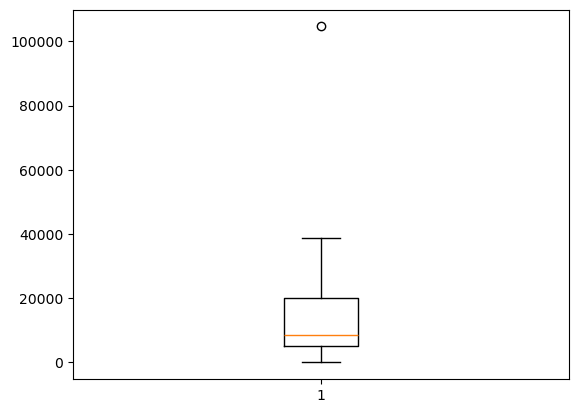

In [13]:
plt.boxplot(df['monthly_sales'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1f8c9e55810>,
 'caps': [<matplotlib.lines.Line2D at 0x1f8c9e55a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f8c9e556d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1f8c9e55d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f8c9e55e50>],
 'means': []}

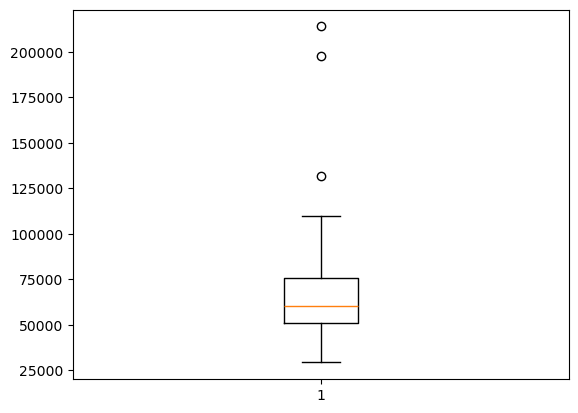

In [14]:
plt.boxplot(df['salary'])

#### Ans: Monthly sales has only one outlier whereas there are three outliers in salary column.

**Exercise 6:** Compute the **90th percentile** for `monthly_sales` and interpret it in one line.

In [15]:
q4=df['monthly_sales'].quantile(0.90)
print(q4)

24424.6


# Hist/Bar/Pie, Frequency Tables, KDE

**Exercise 1:** Plot a **histogram** of `salary` with 25 bins. Add axis labels and a title.

Text(0.5, 1.0, 'Histogram of Salary')

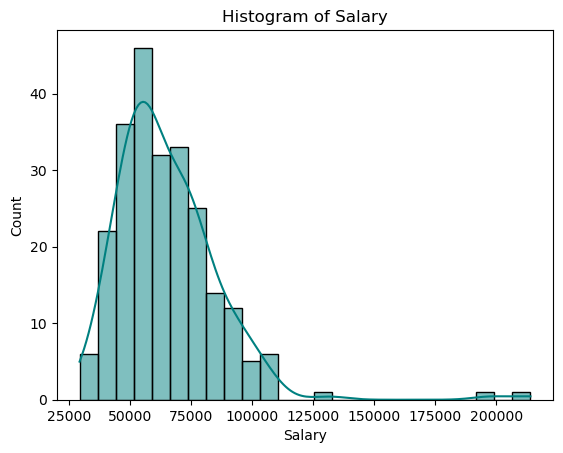

In [16]:
sns.histplot(x=df['salary'],kde=True,bins=25,color='teal')
plt.xlabel("Salary")
plt.ylabel("Count")
plt.title("Histogram of Salary")

**Exercise 2:** Create a **frequency distribution table** for `salary` using 5 equal-width bins via `pd.cut`, and display counts per bin.

In [17]:
pd.cut(df['salary'],bins=5).value_counts().reset_index()

,salary,count
0,"(29147.375, 66257.0]",142
1,"(66257.0, 103182.0]",89
2,"(103182.0, 140107.0]",7
3,"(177032.0, 213957.0]",2
4,"(140107.0, 177032.0]",0


**Exercise 3:** Plot a **KDE** (Kernel Density Estimation) curve for `salary`.

<Axes: xlabel='salary', ylabel='Density'>

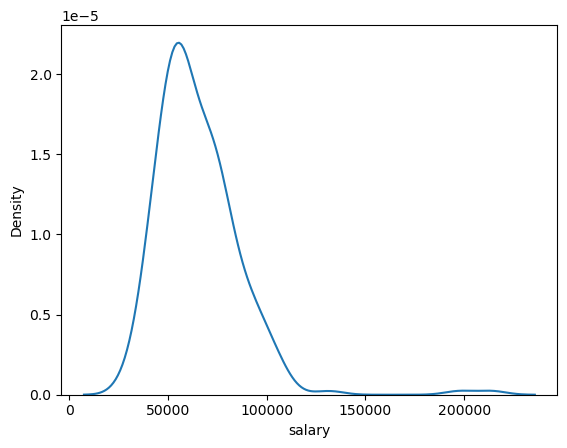

In [18]:
sns.kdeplot(df['salary'])

#### It's right skewed, 

**Exercise 4:** Make a **bar chart** of counts by `department` and a **pie chart** of the same distribution.

[]

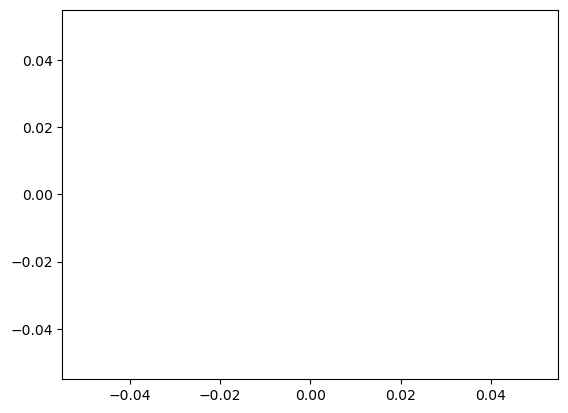

In [19]:
plt.plot(kind='bar',data=df['department'])

# Distribution Shapes, Modality, Visual Outliers

**Exercise 1:** Using `salary`, comment whether it appears **normal or skewed** by comparing histogram + KDE. Also compute **skewness** with `df['salary'].skew()`.

**Exercise 2:** Check **modality** visually: for `monthly_sales`, plot histogram (30 bins) + KDE and briefly note if it looks uni- or multi-modal.

**Exercise 3:** Identify any **visual outliers** in `years_experience` using a box plot and print the suspected outlier values using IQR logic.

# Scatter, Covariance & Pearson Correlation

**Exercise 1:** Create a **scatter plot** of `years_experience` (x) vs `salary` (y). Describe visually: positive, negative, or no relationship?

**Exercise 2:** Compute the **covariance** and **Pearson correlation** between `years_experience` and `salary` using `cov()` and `corr()`.

**Exercise 3:** Compute the **correlation matrix** for numeric columns `[salary, monthly_sales, years_experience, age, work_hours_per_week]` (drop NAs).

**Exercise 4:** Show one example each of **positive**, **negative**, and **near-zero** correlations from the matrix (if present). Write 1-line comments.

**Exercise 5:** **Correlation ≠ Causation:** in 1–2 lines, explain why a high correlation here does not guarantee a causal relationship.

# Cross-tabulations & Stacked Bar Charts; Numeric vs Categorical

**Exercise 1:** Create a **cross-tabulation** of `department` vs `region` and display counts.

**Exercise 2:** Plot the cross-tab above as a **stacked bar chart** (counts).

**Exercise 3:** Create a normalized cross-tab (row-wise proportions) for `gender` vs `education_level` and plot as a stacked bar chart.

**Exercise 4:** Numeric vs Categorical: compute **mean salary by department** and visualize with a **bar chart**.

**Exercise 5:** Numeric vs Categorical: make a **box plot** of `monthly_sales` by `department` to compare distributions across groups.